<a href="https://colab.research.google.com/github/singhm9283-bot/linear-regression/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [158]:
##from google.colab import files
#uploaded= files.upload()

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [160]:
df= pd.read_csv('car_data.csv')

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [162]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


CHECKING FOR THE MISSING VALUES-

In [163]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


CHECKING FOR THE UNIQUE VALUES

In [164]:
df['fuel'].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [165]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [166]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [167]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Fourth & Above Owner',
       'Third Owner', 'Test Drive Car'], dtype=object)

Create a new feature as car's age is necessary feature-

In [168]:
df['Car_Age'] = 2026 - df['year']

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


REMOVING UNNECESSARY COLUMN-

In [169]:
df.drop(['name', 'year'], axis=1, inplace=True)

df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age
0,60000,70000,Petrol,Individual,Manual,First Owner,19
1,135000,50000,Petrol,Individual,Manual,First Owner,19
2,600000,100000,Diesel,Individual,Manual,First Owner,14
3,250000,46000,Petrol,Individual,Manual,First Owner,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,12


ENCODING OF FEATURES

In [170]:
df = pd.get_dummies(
    df,
    columns=['fuel', 'seller_type', 'transmission','owner'],
    drop_first=True
)

df.head()

,selling_price,km_driven,Car_Age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,19,False,False,False,True,True,False,True,False,False,False,False
1,135000,50000,19,False,False,False,True,True,False,True,False,False,False,False
2,600000,100000,14,True,False,False,False,True,False,True,False,False,False,False
3,250000,46000,9,False,False,False,True,True,False,True,False,False,False,False
4,450000,141000,12,True,False,False,False,True,False,True,False,True,False,False


FEATURES AND TARGET-

In [171]:
X= df.drop('selling_price', axis=1)
y = df['selling_price']

TRAINING AND TESTING

In [172]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3472, 13)
Testing Data Shape: (868, 13)


In [173]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

Mean Absolute Error(MAE)

In [174]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 221706.36930930085


Mean Squared Error(MSE)

In [175]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 182146878750.28098


R2 Score

In [176]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.4031303601432117


GRAPHICAL ANALYSIS -

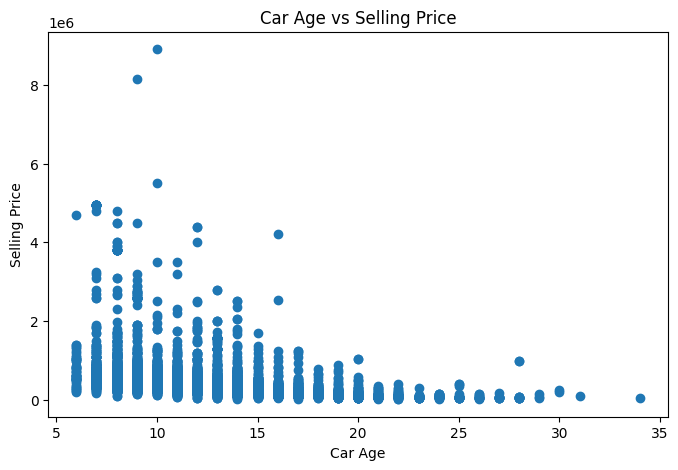

In [177]:


plt.figure(figsize=(8,5))

plt.scatter(df['Car_Age'], df['selling_price'])

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

USER INPUT

In [178]:
print("\nEnter Car Details")


kms_driven = int(input("Kilometers Driven: "))
owner = int(input("Number of Previous Owners: "))
car_age = int(input("Car Age: "))

fuel_type_diesel = int(input("Fuel Type Diesel? (1=Yes,0=No): "))
fuel_type_petrol = int(input("Fuel Type Petrol? (1=Yes,0=No): "))
fuel_type_electric = int(input("Fuel Type Electric? (1=Yes,0=No): "))
fuel_type_lpg = int(input("Fuel Type LPG? (1=Yes,0=No): "))

seller_type_individual = int(input("Seller Individual? (1=Yes,0=No): "))
seller_type_trustmark_dealer = int(input("Seller Trustmark Dealer? (1=Yes,0=No): "))

transmission_manual = int(input("Manual Transmission? (1=Yes,0=No): "))



Enter Car Details
Kilometers Driven: 50000
Number of Previous Owners: 2
Car Age: 14
Fuel Type Diesel? (1=Yes,0=No): 1
Fuel Type Petrol? (1=Yes,0=No): 0
Fuel Type Electric? (1=Yes,0=No): 0
Fuel Type LPG? (1=Yes,0=No): 0
Seller Individual? (1=Yes,0=No): 1
Seller Trustmark Dealer? (1=Yes,0=No): 0
Manual Transmission? (1=Yes,0=No): 1


INPUT DATAFRAME


In [179]:
1
1
user_input_data = {
    'km_driven': kms_driven,
    'Car_Age': car_age,
    'fuel_Diesel': 0,
    'fuel_Petrol': 0,
    'fuel_Electric': 0,
    'fuel_LPG': 0,

    'seller_type_Individual': 0,
    'seller_type_Trustmark Dealer': 0,
    'transmission_Manual': 0,
    'owner_Fourth & Above Owner': 0,
    'owner_Second Owner': 0,
    'owner_Test Drive Car': 0,
    'owner_Third Owner': 0
}

# Handle owner input for one-hot encoding
if owner == 2:
    user_input_data['owner_Second Owner'] = 1
elif owner == 3:
    user_input_data['owner_Third Owner'] = 1
elif owner >= 4:
    user_input_data['owner_Fourth & Above Owner'] = 1

user_data = pd.DataFrame([user_input_data], columns=X.columns)

predicted_price = lr_model.predict(user_data)

print("\nPredicted Selling Price:")
print(round(predicted_price[0],2), )


Predicted Selling Price:
1176789.22
